# 04 - Model Training and Comparison

We train several regression models on the engineered dataset and compare them using cross-validated RMSE on the log-transformed target.

Models:
- Linear Regression (baseline)
- Ridge Regression (L2 regularization)
- Lasso Regression (L1 regularization)
- Random Forest Regressor
- XGBoost Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load the model-ready dataset

In [2]:
df = pd.read_csv('../data/processed/train_features.csv')

X = df.drop(columns=['SalePrice_log'])
y = df['SalePrice_log']

X.shape, y.shape

((1456, 244), (1456,))

## 2. Train / test split

We hold out 20% of the data to evaluate the final models on data they never saw during training or cross-validation.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((1164, 244), (292, 244))

## 3. Scale features for linear models

Linear/Ridge/Lasso are sensitive to feature scale (e.g. `LotArea` in the thousands vs a 0/1 flag). Tree-based models (Random Forest, XGBoost) don't need this.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Define models

In [5]:
models = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge': (Ridge(alpha=10, random_state=RANDOM_STATE), True),
    'Lasso': (Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000), True),
    'Random Forest': (RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), False),
    'XGBoost': (XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                              random_state=RANDOM_STATE, n_jobs=-1), False),
}
# (model, needs_scaling)

## 5. Cross-validation comparison

We use 5-fold cross-validation on the training set (RMSE on the log target) to compare models before touching the test set.

In [6]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, (model, needs_scaling) in models.items():
    data_X = X_train_scaled if needs_scaling else X_train
    scores = cross_val_score(model, data_X, y_train, cv=kfold,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    results.append({
        'model': name,
        'cv_rmse_mean': rmse_scores.mean(),
        'cv_rmse_std': rmse_scores.std()
    })

cv_results = pd.DataFrame(results).sort_values('cv_rmse_mean')
cv_results

,model,cv_rmse_mean,cv_rmse_std
2,Lasso,0.118074,0.009020
1,Ridge,0.122752,0.010511
4,XGBoost,0.124153,0.010089
0,Linear Regression,0.126457,0.011350
3,Random Forest,0.133292,0.015363


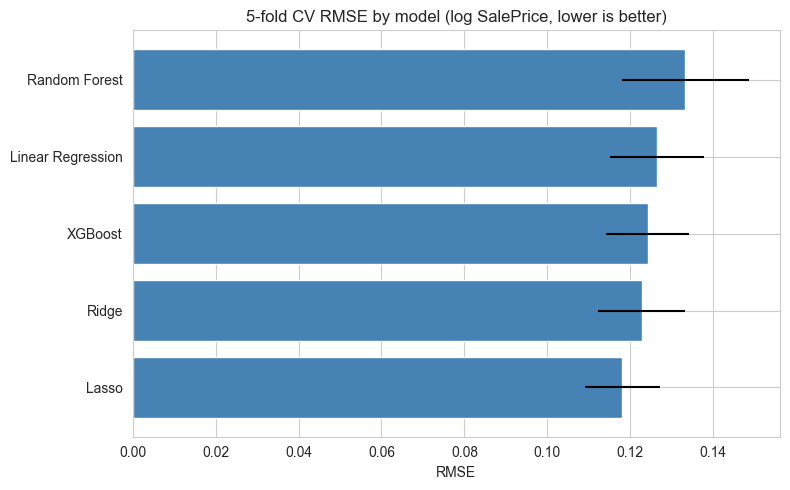

In [7]:
plt.figure(figsize=(8, 5))
plt.barh(cv_results['model'], cv_results['cv_rmse_mean'],
         xerr=cv_results['cv_rmse_std'], color='steelblue')
plt.title('5-fold CV RMSE by model (log SalePrice, lower is better)')
plt.xlabel('RMSE')
plt.tight_layout()
plt.show()

## 6. Fit each model on the full training set, evaluate on the held-out test set

In [8]:
test_results = []

for name, (model, needs_scaling) in models.items():
    train_X = X_train_scaled if needs_scaling else X_train
    test_X = X_test_scaled if needs_scaling else X_test

    model.fit(train_X, y_train)
    preds = model.predict(test_X)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    test_results.append({'model': name, 'test_rmse': rmse, 'test_r2': r2})

test_results = pd.DataFrame(test_results).sort_values('test_rmse')
test_results

,model,test_rmse,test_r2
4,XGBoost,0.123354,0.903657
2,Lasso,0.125567,0.900170
1,Ridge,0.129558,0.893723
0,Linear Regression,0.130109,0.892817
3,Random Forest,0.142341,0.871715


## 7. Final comparison table

In [9]:
comparison = cv_results.merge(test_results, on='model').sort_values('test_rmse')
comparison

,model,cv_rmse_mean,cv_rmse_std,test_rmse,test_r2
2,XGBoost,0.124153,0.010089,0.123354,0.903657
0,Lasso,0.118074,0.009020,0.125567,0.900170
1,Ridge,0.122752,0.010511,0.129558,0.893723
3,Linear Regression,0.126457,0.011350,0.130109,0.892817
4,Random Forest,0.133292,0.015363,0.142341,0.871715


## 8. Save the best model

XGBoost had the best test RMSE and R², so we pick it as the final model. We retrain it on the **entire** dataset (train + test combined) so it learns from every available row before being used for real predictions — the earlier train/test split was only needed to compare models fairly.

We also save the list of feature columns. The FastAPI service will need this later to make sure a new house's data lines up with the exact same columns (in the same order) that the model was trained on, especially after one-hot encoding.

In [10]:
import joblib
import json
import os

final_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                            random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(X, y)

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/xgboost_model.pkl')

with open('../models/feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)

print(f'Model saved. Trained on {X.shape[0]} rows, {X.shape[1]} features.')

Model saved. Trained on 1456 rows, 244 features.
